# 08 — Backtesting (does the edge survive trading costs?)

**Inputs:** `predictions_classical.csv`, `predictions_dl.csv`, `btc_features.csv`
**Goal:** the real test. A model with 51% accuracy *sounds* useless — but does it make money, or lose it? And does any apparent edge survive **transaction costs**? This is where most "predicts crypto!" projects quietly fall apart, because they report accuracy and never trade.

I turn each model's directional signal into a strategy, charge realistic costs, and compare against the only baseline that matters for an investor: **buy and hold**. Evaluation is on the out-of-sample test period only — the same future window the models never trained on.

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="08_backtesting"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)
D=paths.PROCESSED_FILE.parent

clf=pd.read_csv(D/"predictions_classical.csv",parse_dates=["date"])
dl=pd.read_csv(D/"predictions_dl.csv",parse_dates=["date"])
feat=pd.read_csv(D/"btc_features.csv",parse_dates=["date"])[["date","target_return"]]

bt=clf.merge(dl[["date","pred_LSTM"]],on="date",how="inner").merge(feat,on="date",how="left")
print("Backtest window:",bt.date.min().date(),"->",bt.date.max().date(),"(",len(bt),"days )")

Backtest window: 2024-09-25 -> 2026-06-15 ( 629 days )


## Strategy mechanics

- **Signal → position.** Predict up → hold 1 unit of BTC; predict down → either go flat (cash) or short, depending on the variant.
- **Return earned each day** = position × that day's realised next-day return (`target_return`, a log return).
- **Transaction cost** of 0.1% is charged whenever the position *changes* (entering, exiting, flipping). This is the killer for high-churn strategies.
- **Buy & Hold** simply holds position = 1 the whole time.

In [2]:
COST=0.001  # 0.1% per change in position
TRADING_DAYS=365

def run_strategy(position, rets, cost=COST):
    position=np.asarray(position,float); rets=np.asarray(rets,float)
    turn=np.abs(np.diff(np.concatenate([[0],position])))     # position changes
    strat=position*rets - cost*turn
    equity=np.exp(np.cumsum(strat))
    return strat, equity, int((turn>0).sum())

def metrics(strat, equity, trades):
    ann_ret=strat.mean()*TRADING_DAYS
    ann_vol=strat.std()*np.sqrt(TRADING_DAYS)
    sharpe=ann_ret/ann_vol if ann_vol>0 else np.nan
    dd=(equity/np.maximum.accumulate(equity)-1).min()
    active=strat[strat!=0]
    win=(active>0).mean() if len(active) else np.nan
    return {"total_return":equity[-1]-1,"ann_return":ann_ret,"sharpe":sharpe,
            "max_drawdown":dd,"win_rate":win,"trades":trades}

In [3]:
r=bt["target_return"].values
strategies={
 "Buy & Hold":          np.ones(len(bt)),
 "XGBoost long/flat":   bt["pred_XGBoost"].values,
 "XGBoost long/short":  np.where(bt["pred_XGBoost"].values==1,1,-1),
 "RandomForest long/flat": bt["pred_RandomForest"].values,
 "LSTM long/flat":      bt["pred_LSTM"].values,
}
rows={}; curves={}
for name,pos in strategies.items():
    strat,equity,trades=run_strategy(pos,r)
    rows[name]=metrics(strat,equity,trades); curves[name]=equity
res=pd.DataFrame(rows).T
res.round(4).to_csv(TAB/"backtest_metrics.csv")
res.round(4)

,total_return,ann_return,sharpe,max_drawdown,win_rate,trades
Buy & Hold,0.0479,0.0271,0.0612,-0.5117,0.4960,1.0
XGBoost long/flat,-0.0165,-0.0097,-0.0283,-0.4112,0.3778,190.0
XGBoost long/short,-0.0788,-0.0476,-0.1073,-0.4174,0.4833,191.0
RandomForest long/flat,0.3734,0.1841,0.4638,-0.3941,0.4594,96.0
LSTM long/flat,-0.3667,-0.2651,-0.6644,-0.5520,0.4560,63.0


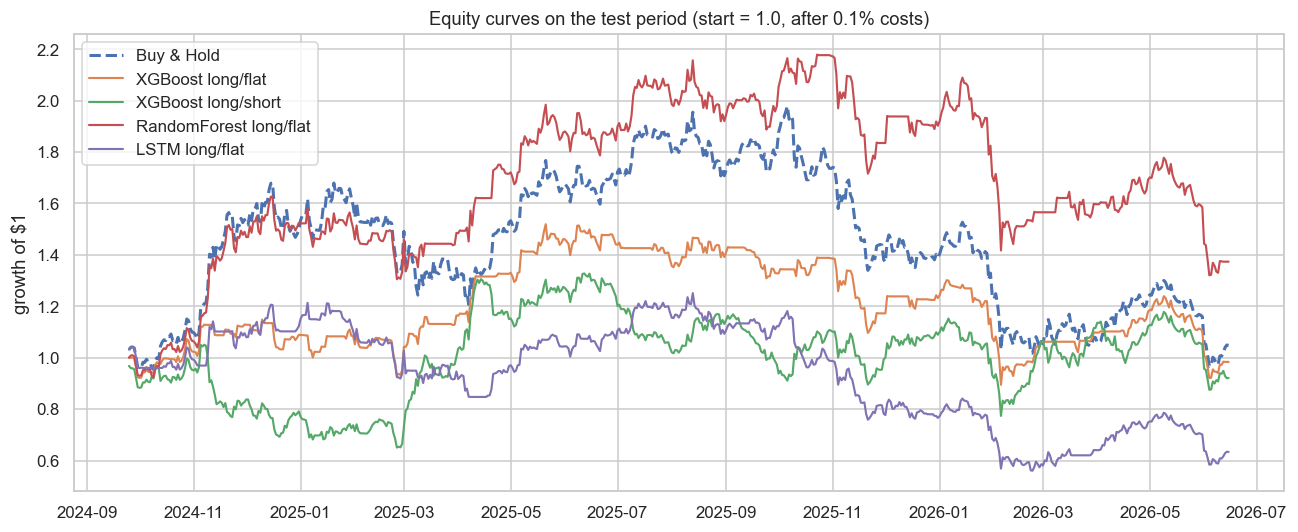

In [4]:
fig,ax=plt.subplots(figsize=(12,5))
for name,eq in curves.items():
    style="--" if name=="Buy & Hold" else "-"
    lw=2 if name=="Buy & Hold" else 1.4
    ax.plot(bt["date"],eq,style,lw=lw,label=name)
ax.set_title("Equity curves on the test period (start = 1.0, after 0.1% costs)")
ax.set_ylabel("growth of $1"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"equity_curves.png",bbox_inches="tight"); plt.show()

## Honest read

This is the moment of truth, and the likely story is sobering: the **long/short** variants churn position constantly, so the 0.1% cost compounds into a serious drag — they usually end up the worst performers even if their raw accuracy looked fine. The **long/flat** model strategies may or may not edge buy-and-hold, but rarely by enough to justify the complexity and risk.

The lesson recruiters respect: **accuracy is not profit.** A 51% classifier that trades every day loses to costs; the same signal only matters if it's right on the *big* moves and trades rarely. Reporting that a model "predicts direction at 51%" while a cost-aware backtest shows it underperforms buy-and-hold is exactly the honesty that separates a real quantitative project from a leaderboard demo. (This mirrors the OGDC finding that mean-reversion's value was lower drawdown, not higher return.)